# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


- **Sumber Dataset**: Kaggle ([Stephan Matzka - Predictive Maintenance Dataset (AI4I 2020)])
- **Objektif**: Melakukan Predictive Maintenance untuk memprediksi kegagalan mesin berdasarkan data sensor.
- **Format Data**: CSV (Comma-Separated Values)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur agar semua kolom yang di tampilkan saat memanggil data
pd.set_option('display.max_columns', None)

print("Library dasar berhasil di-import!")

Library dasar berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [24]:
# Masukan nama file CSV
data_path = 'predictive_maintenance_ai4i2020.csv'

# Membaca dataset
df = pd.read_csv(data_path)

# Membuat 5 baris pertama untuk pengecekan struktur datanya
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [25]:
# 1. Melihat informasi dasar dataset (Jumlah baris, nama kolom, tipe data, dan missing valuer)
print("--- Informasi Dataset ---")
df.info()

print("\n--- Jumlah Baris & Kolom ---")
print(f"Dataset ini memiliki {df.shape[0]} baris dan {df.shape[1]} kolom.")

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dt

**Kesimpulan Struktur Data :**

- Ukuran Data: Dataset ini memiliki 10.000 baris dan 14 kolom.

- Tidak Ada Missing Value (Data Kosong): Semua kolom memiliki 10000 non-null, yang artinya datanya lengkap dan tidak ada yang bolong. Bagus sekali!

**Tipe Data :**

- Ada 12 kolom numerik (float64 untuk desimal dan int64 untuk angka bulat). Kolom seperti Air temperature, Rotational speed, dan Torque adalah data sensor penunjang utama.

- Ada 2 kolom kategorik/teks (object), yaitu Product ID dan Type.

- Target Prediksi: Kolom Machine failure (angka 0 atau 1) akan menjadi target utama untuk memprediksi apakah mesin rusak atau tidak.

In [26]:
# Memeriksa Duplikasi dan Ringkasan Statistik
# 2. Memeriksa jumlah data duplikat
print(f"Jumlah data yang terduplikat: {df.duplicated().sum()}")

# 3. Menampilkan ringkasan statistik untuk kolom numerik
print("\n--- Ringkasan Statistik Data Numerik ---")
df.describe()

Jumlah data yang terduplikat: 0

--- Ringkasan Statistik Data Numerik ---


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**Kesimpulan :**

1. Tidak Ada Data Duplikat
Jumlah data yang terduplikat: 0. Artinya setiap baris data merepresentasikan kondisi mesin yang unik, tidak ada pemborosan memori.

2. Rentang Nilai Sensor Sangat Berbeda (Skala Data Berbeda) Jika di
perhatikan nilai minimum (min) dan maksimum (max) antar kolom sensor:

- Air temperature: bergerak di kisaran 295.3 sampai 304.5.

- Rotational speed: bergerak dari 1168 sampai 2886.

- Torque: bergerak dari 3.8 sampai 76.6.

- Kesimpulan: Karena rentang angkanya sangat timpang (ada yang ratusan, ada yang ribuan), ini wajib melakukan Scaling (seperti StandardScaler atau MinMaxScaler) agar model machine learning tidak bingung.

3. Ketidakseimbangan Data (Imbalanced Dataset) yang Ekstrem!
Kolom Machine failure pada baris mean (rata-rata) Nilainya adalah 0.033900.

- Artinya, data mesin yang rusak (failure = 1) hanya sekitar 3.39% dari total 10.000 data. Sisanya (96.61%) adalah data mesin yang normal (Machine failure = 0).

- Kesimpulan: Dataset ini mengalami imbalance parah. Ini harus dicatat karena sangat krusial untuk penanganan di tahap preprocessing atau pemodelan nanti.

/tmp/ipykernel_6157/3995148128.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, palette='Set2')


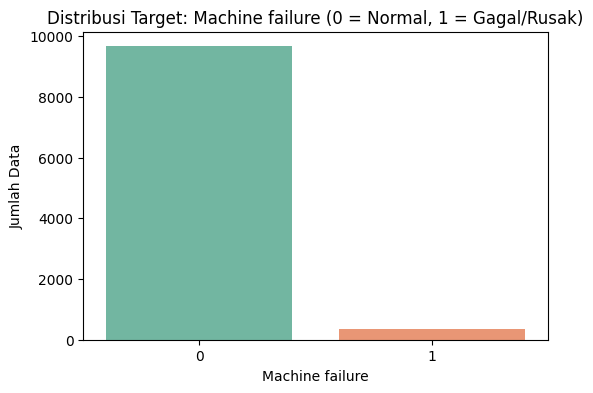

Jumlah masing-masing kelas:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [27]:
# Visualisasi Data Target
# 4. Membuat Visualisasi distrubusi variabel target 'Machine failure'
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df, palette='Set2')
plt.title('Distribusi Target: Machine failure (0 = Normal, 1 = Gagal/Rusak)')
plt.xlabel('Machine failure')
plt.ylabel('Jumlah Data')
plt.show()

# 5. Menampilkan angka pastinya
print("Jumlah masing-masing kelas:")
print(df['Machine failure'].value_counts())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [29]:
# 1. Menghapus atau Menangani Data Kosong (Missing Values) = Tiadak ada data Kosong sudah di pastikan di tahap EDA
# 2. Menghapus Data Duplikat = Tidak ada data duplikat sudah di pastikan di tahap EDA
# 3. Encoding Data Kategorikal
from sklearn.preprocessing import StandardScaler

# 3.1 Drop kolom yang tidak relevan
columns_to_drop = ['UDI', 'Product ID']
df_clean = df.drop(columns=columns_to_drop, axis=1)

# 3.2 One-Hot Encoding pada kolom 'Type' (Mengubah teks L, M, H menjadi angka 0 dan 1)
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)
df_clean = df_clean.astype({col: 'int64' for col in df_clean.select_dtypes(include='bool').columns})

# 3.3 Memisahkan Fituer (X) & Target (y)
# Drop kolom 'Machine failure' dari X karena itu adalah target yang akan di tebak
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

# 4. Standarisasi Fitur (Feature Scaling)
# 4.1 Menentukan kolom numerik yang perlu diskalakan (data sensor) agar rata-rata = 0 dan std = 1
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 4.2 Gabungkan kembali dan Simpan menjadi CSV Baru
df_preprocessed = X_scaled.copy()
df_preprocessed['Machine failure'] = y
output_path = 'predictive_maintenance_preprocessed.csv'
df_preprocessed.to_csv(output_path, index=False)

print("--- PROSES PREPROCESSING BERHASIL TOTAL ---")
print(f"File berhasil dibuat: {output_path}")
print(f"Ukuran akhir dataset: {df_preprocessed.shape}")
print(X[numerical_cols].head(2))
df_preprocessed.head(3)


--- PROSES PREPROCESSING BERHASIL TOTAL ---
File berhasil dibuat: predictive_maintenance_preprocessed.csv
Ukuran akhir dataset: (10000, 13)
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_L,Type_M,Machine failure
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,0,0,0,0,0,1,0
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,0,0,0,0,1,0,0
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,0,0,0,0,1,0,0


**Kesimpulan :**

Nilai sensornya sekarang sudah berbentuk desimal standar hasil scaling (skalanya setara), kolom identitas sudah hilang, dan tipe kualitas mesin sudah sukses dikonversi menjadi Type_L serta Type_M.

In [30]:
# Membuat file automate_Dedy_Hendarko.py langsung dari Google Colab
script_code = """
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def load_data(file_path):
  \"\"\"Memuat dataset dari jalur file\"\"\"
  return pd.read_csv(file_path)

def preprocess_data(df):
  \"\"\"Melakukan otomasi seluruh tahapan preprocessing\"\"\"
  df_clean = df.copy()

  # 1. Hapus kolom identitas
  columns_to_drop = ['UDI', 'Product ID']
  df_clean = df_clean.drop(columns=columns_to_drop, axis=1, errors='ignore')

  # 2. One-Hot Encoding pada kolom 'Type'
  if 'Type' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)
    # Pastikan tipenya angka bulat agar aman di GitHub Actions
    df_clean = df_clean.astype({col: 'int64' for col in df_clean.select_dtypes(include='bool').columns})

  # 3. Pisahkan Fitur dan Target
  if 'Machine failure in df_clean.columns:
    X = df_clean.drop(columns=['Machine failure'])
    y = df_clean['Machine failure']
  else:
    X = df_clean
    y = None

  # 4. Standarisasi Fiture Numerik
  numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
  scaler = StandardScaler()
  X_scaled = X.copy()
  X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

  # 5. Gabungkan kembali jika ada target
  if y is not None:
    df_final =X_scaled.copy()
    df_final['Machine failure'] = y
  else:
    df_final = X_scaled

  return df_final

if __name__ == "__main__":
  import os

  # Tentukan jalur file (ini disesuaikan dengan nama file asli Dedy_Hendarko)
  input_file = 'namadataset_raw/predictive_maintenance_ai4i2020.csv'
  output_dir = 'preprocessing/namadataset_preprocessing'
  output_file = os.path.join(output_dir, 'predictive_maintenance_preprocessing.csv')

  # Jalankan jika file input ada (untuk testing local/workflow)
  if os.path.exists(input_file):
    print("Memulai otomatisasi preprocessing...")
    raw_data = load_data(input_file)
    clean_data = preprocess_data(raw_data)

    os.makedirs(output_dir, exist_ok=True)
    clean_data.to_csv(output_file, index=False)
    print(f"Sukses! Data Siap latih & disimpan di: {output_file}")
  else:
    print(f"File {input_file} tidak ditemukan. Otomatisasi siap digunakan dalam workflow.")

"""

# Perintah menulis string menjadi file dengan nama baru
with open('automate_Dedy_Hendarko.py', 'w') as f:
  f.write(script_code.strip())

print("File automate_Dedy_Hendarko.py berhasil diciptakan di storage Colab!")




File automate_Dedy_Hendarko.py berhasil diciptakan di storage Colab!


**Hasil sudah terkoneksi ke Github :**

- Bisa berjalan otomatis terjadwal seminggu sekali (setiap hari Senin).

- Bisa dijalankan manual kapan saja (tombol Run workflow).

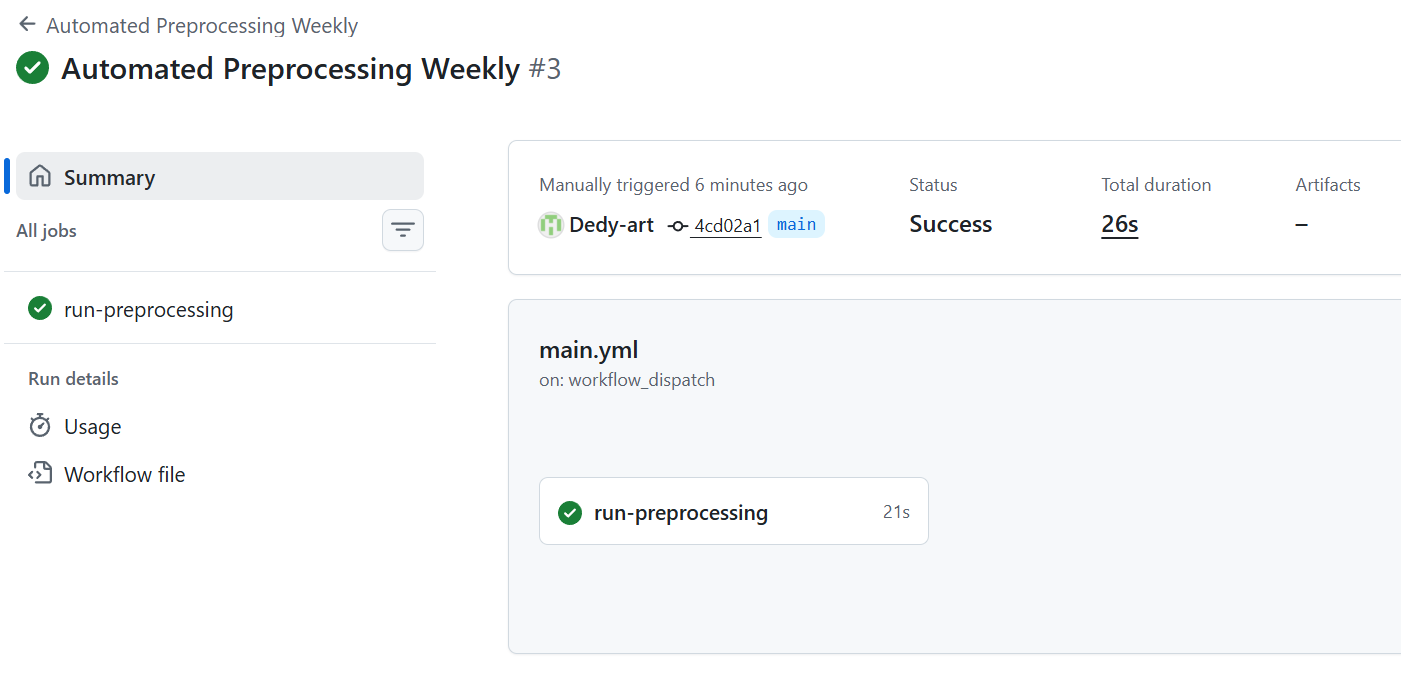